# Unsupervised Machine Learning Project: Clustering

## 1. Project Objective
The objective of this project is to apply **Unsupervised Machine Learning dimensionality reduction and clustering techniques** to identify patterns in a telekom dataset (`churndata_processed.csv`).

In this project we will:
- Perform **Principal Component Analysis (PCA)** to reduce feature dimensionality.
- Build and compare the following clustering models:
  1. **K-Means**
  2. **Agglomerative Hierarchical Clustering**
  3. **Density-Based Spatial Clustering of Applications with Noise (DBSCAN)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2. Dataset Selection & Description
The dataset for this project is the `churndata_processed.csv`

In [2]:
df = pd.read_csv('churndata_processed.csv')

df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   months                     7043 non-null   float64
 1   multiple                   7043 non-null   int64  
 2   gb_mon                     7043 non-null   float64
 3   security                   7043 non-null   int64  
 4   backup                     7043 non-null   int64  
 5   protection                 7043 non-null   int64  
 6   support                    7043 non-null   int64  
 7   unlimited                  7043 non-null   int64  
 8   contract                   7043 non-null   float64
 9   paperless                  7043 non-null   int64  
 10  monthly                    7043 non-null   float64
 11  satisfaction               7043 non-null   float64
 12  churn_value                7043 non-null   int64  
 13  payment_Credit Card        7043 non-null   int64

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,...,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.433551,0.421837,0.241358,0.286668,0.344881,0.343888,0.290217,0.673719,0.377396,0.592219,...,0.390317,0.054664,0.234559,0.430924,0.216669,0.073832,0.116996,0.058924,0.085475,0.114298
std,0.398231,0.493888,0.240223,0.452237,0.475363,0.475038,0.453895,0.468885,0.424234,0.491457,...,0.487856,0.227340,0.423753,0.495241,0.412004,0.261516,0.321438,0.235499,0.279607,0.318195
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.035294,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.250000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.750000,1.000000,0.317647,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Data Preproccessing

In [3]:
X = df.drop(columns=['churn_value'])
y = df['churn_value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# print(X)
# print(X_scaled)

## 3. Dimensionality Reduction (PCA)

We apply **PCA** to extract 2 Principal Components for our models.

In [4]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

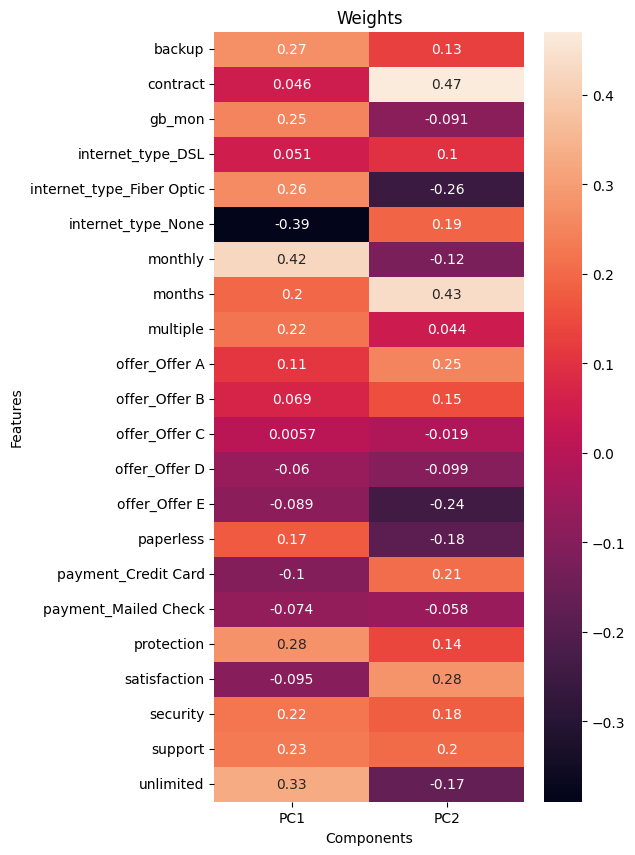

In [5]:
pc1_weights = pd.Series(pca.components_[0].T, index=X.columns, name='PC1').rename_axis(None).sort_values(ascending=False)
pc2_weights = pd.Series(pca.components_[1].T, index=X.columns, name='PC2').rename_axis(None).sort_values(ascending=False)

weights_df = pd.DataFrame({'PC1': pc1_weights, 'PC2': pc2_weights})

plt.figure(figsize=(5, 10))
sns.heatmap(weights_df, annot=True)

plt.title('Weights')
plt.ylabel('Features')
plt.xlabel('Components')
plt.show()


## 4. Model Development

### Model 1: K-Means

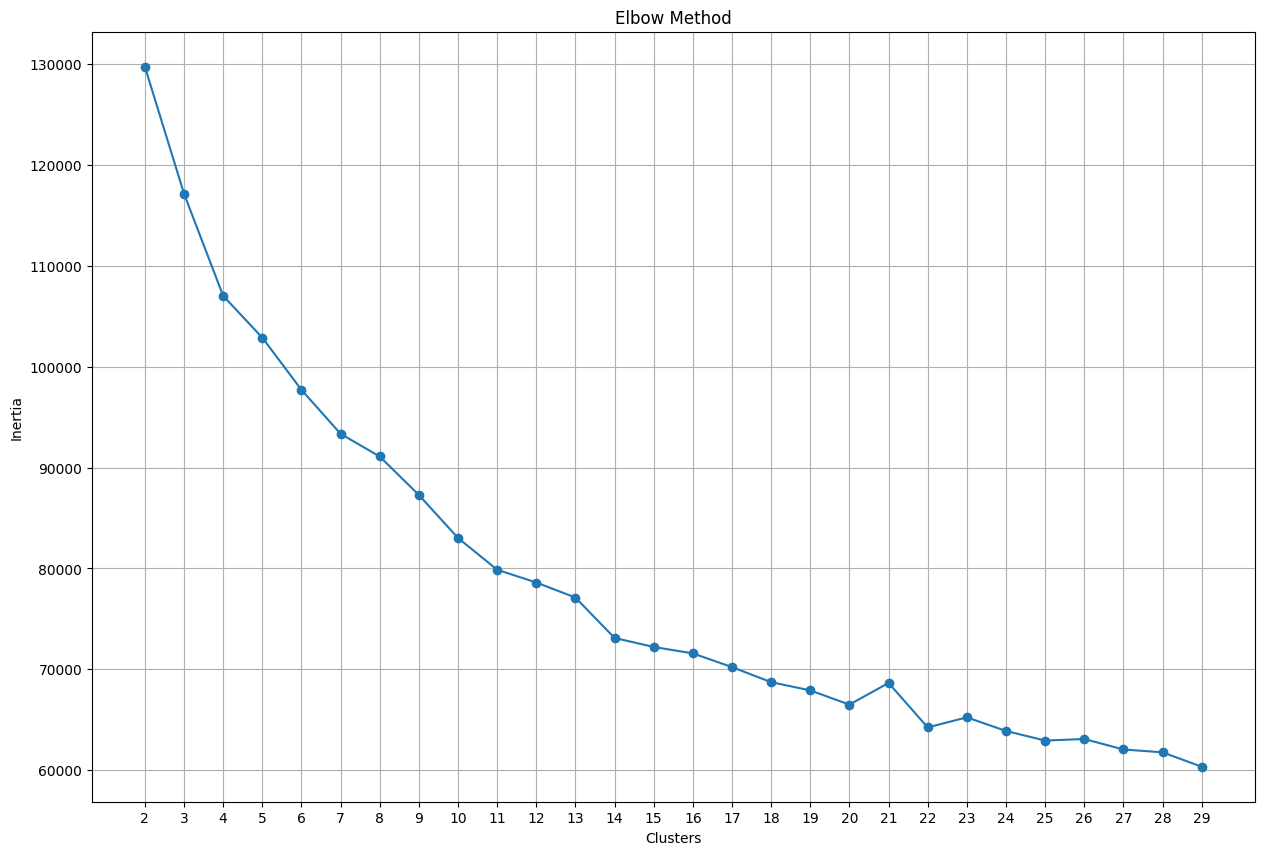

In [52]:
inertia = []
clusters = range(2, 30)
silhouette_kmeans = []

for c in clusters:
  kmeans = KMeans(n_clusters=c, random_state=0)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)
  silhouette_kmeans.append(silhouette_score(X_scaled, kmeans.labels_))

frame = pd.DataFrame({'Cluster':clusters, 'Inertia':inertia})
plt.figure(figsize=(15,10))
plt.plot(frame['Cluster'], frame['Inertia'], marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.xticks(clusters)
plt.show()

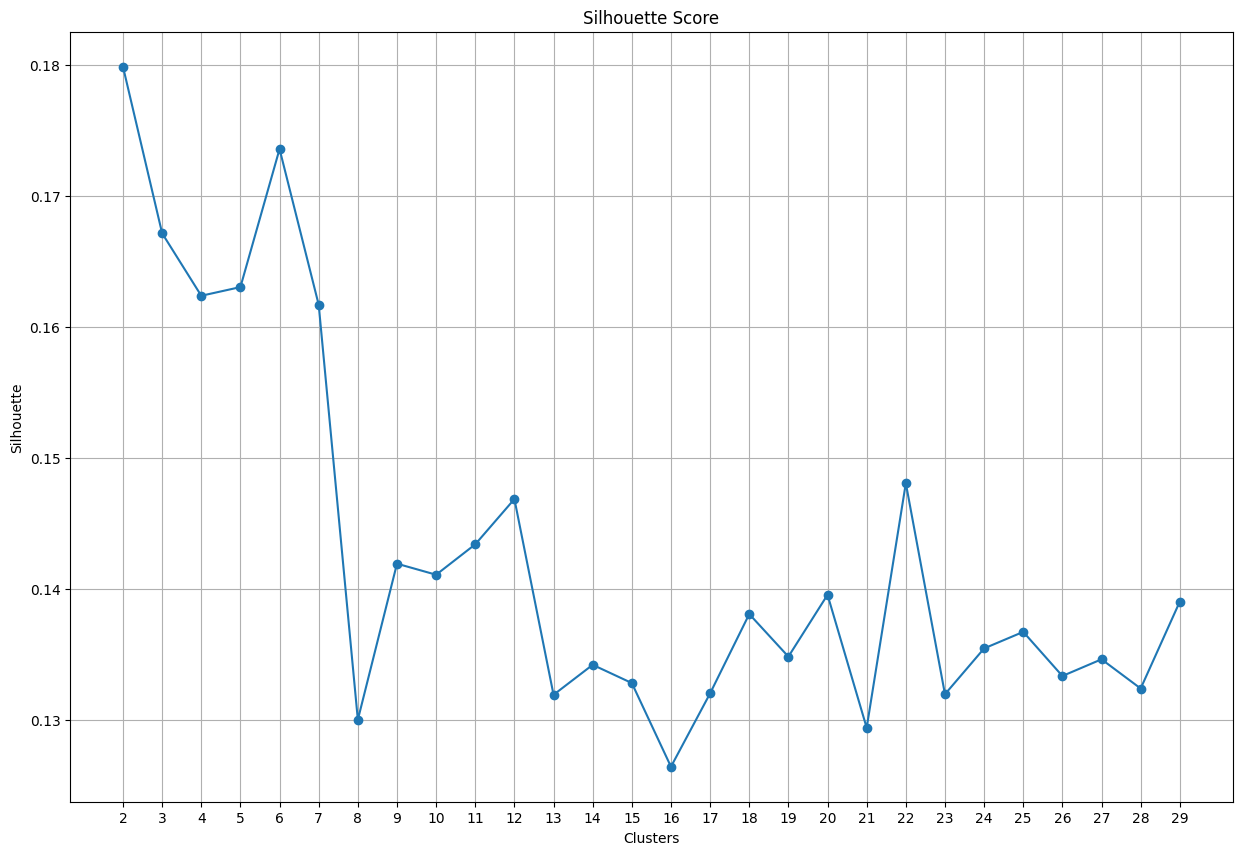

In [51]:
frame = pd.DataFrame({'Cluster':clusters, 'Silhouette':silhouette_kmeans})
plt.figure(figsize=(15,10))
plt.plot(frame['Cluster'], frame['Silhouette'], marker='o')
plt.title('Silhouette Score')
plt.xlabel('Clusters')
plt.ylabel('Silhouette')
plt.grid(True)
plt.xticks(clusters)
plt.show()

The Inertia becomes less steep around **$4-7$** clusters while the Silhouette Score peak at **$K = 6$** clusters so we select **$K = 6$**.

In [54]:
best_kmeans = KMeans(n_clusters=6, random_state=0)
kmeans_labels = best_kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score: ", kmeans_silhouette)

K-Means Silhouette Score:  0.17358494102094912


### Model 2: Agglomerative Hierarchical Clustering

In [91]:
agg = AgglomerativeClustering(n_clusters=6, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

agg_silhouette = silhouette_score(X_scaled, agg_labels)

print("Agglomerative Hierarchical Clustering Silhouette Score: ", agg_silhouette)

Agglomerative Hierarchical Clustering Silhouette Score:  0.15847609545303912


### Model 3: Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

In [93]:
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca)
core_samples_mask = dbscan_labels != -1
unique_labels = set(dbscan_labels)
n_clusters = len(unique_labels - {-1})
n_noise = list(dbscan_labels).count(-1)
dbscan_silhouette = silhouette_score(X_pca[core_samples_mask], dbscan_labels[core_samples_mask])

print("Clusters: ", n_clusters)
print(f"Noise points: {n_noise} out of {len(X)}")
print("DBSCAN Silhouette Score : ", dbscan_silhouette)

Clusters:  2
Noise points: 75 out of 7043
DBSCAN Silhouette Score :  0.49808358988478585


## 5. Model Selection

In [94]:
metrics_df = pd.DataFrame({
  "Model": ['K-Means', 'HAC', 'DBSCAN'],
  "Silhouette Score": [kmeans_silhouette, agg_silhouette, dbscan_silhouette],
})

metrics_df

,Model,Silhouette Score
0,K-Means,0.173585
1,HAC,0.158476
2,DBSCAN,0.498084


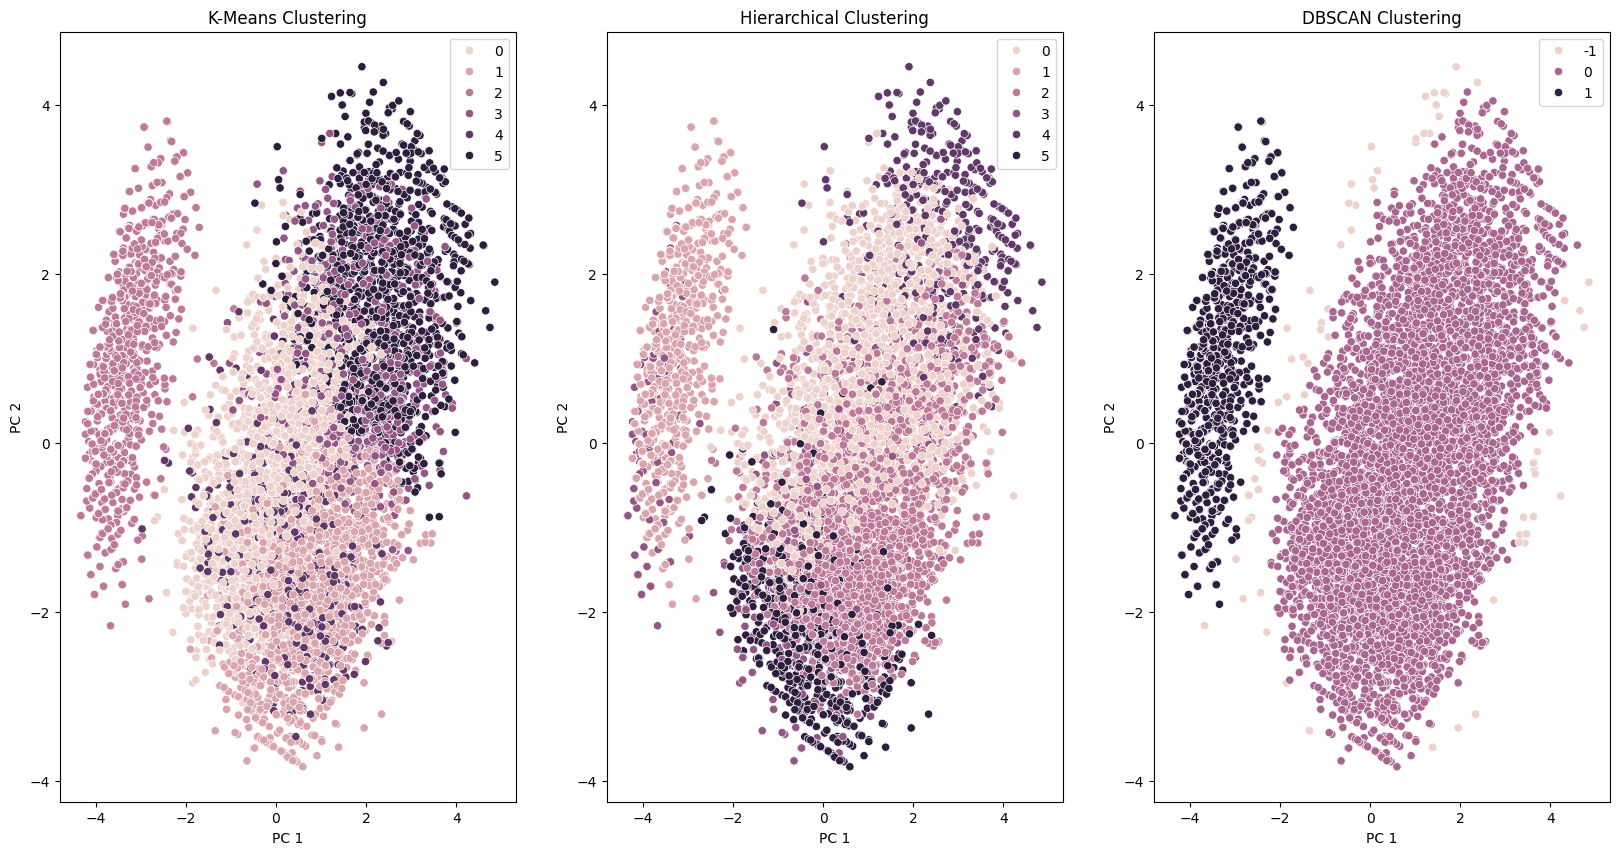

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=axes[0], hue=kmeans_labels)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')

# HAC
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=axes[1], hue=agg_labels)
axes[1].set_title('Hierarchical Clustering')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')

# DBSCAN
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=axes[2], hue=dbscan_labels)
axes[2].set_title('DBSCAN Clustering')
axes[2].set_xlabel('PC 1')
axes[2].set_ylabel('PC 2')

plt.show()

### Model Performance & Best Model

- **DBSCAN** is the best performing model with a **Silhouette Score = $49.8\%$**.
- **K-Means** is second with a **Silhouette Score = $17.3\%$**.
- **HAC** is third with a **Silhouette Score = $15.8\%$**.